# Credit Wise Loan System
End-to-end supervised ML pipeline for loan approval prediction using KNN, Logistic Regression, and Naive Bayes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Load Data

In [34]:
df = pd.read_csv(r"C:\Users\AYESHA\OneDrive\Desktop\Datasets\loan_approval_data.csv")   
df = df.drop("Applicant_ID", axis=1)
df["Loan_Approved"] = df["Loan_Approved"].replace(["", "NA", "null", "-"], np.nan)  
df = df.dropna(subset=["Loan_Approved"])

X = df.drop("Loan_Approved", axis=1)
Y = df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(df["Loan_Approved"].unique())
print(df["Loan_Approved"].value_counts(dropna=False))
print(set(y_train))
print(set(y_test))

<StringArray>
['No', 'Yes']
Length: 2, dtype: str
Loan_Approved
No     652
Yes    298
Name: count, dtype: int64
{'No', 'Yes'}
{'No', 'Yes'}


## Step 2: Handling Missing Values

In [35]:
cat_cols = X_train.select_dtypes(include=["object", "string"]).columns
num_cols = X_train.select_dtypes(include=["number"]).columns

cat_imp = SimpleImputer(strategy="most_frequent")
num_imp = SimpleImputer(strategy="mean")

X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
X_train[cat_cols] = cat_imp.fit_transform(X_train[cat_cols])

# transform ONLY on test — using values already learned from train
X_test[num_cols] = num_imp.transform(X_test[num_cols])
X_test[cat_cols] = cat_imp.transform(X_test[cat_cols])

print(X_train.isnull().sum())

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
dtype: int64


## Step 3: Exploratory Data Analysis

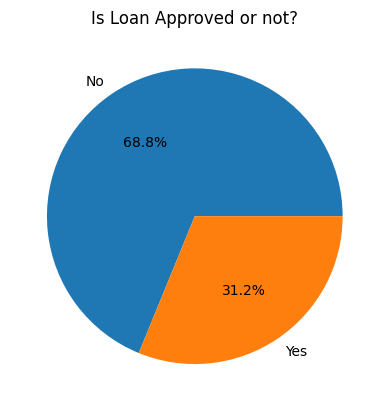

In [36]:
# Class balance
classes_count = y_train.value_counts()
plt.pie(classes_count, labels=["No", "Yes"], autopct="%1.1f%%")
plt.title("Is Loan Approved or not?")
plt.show()

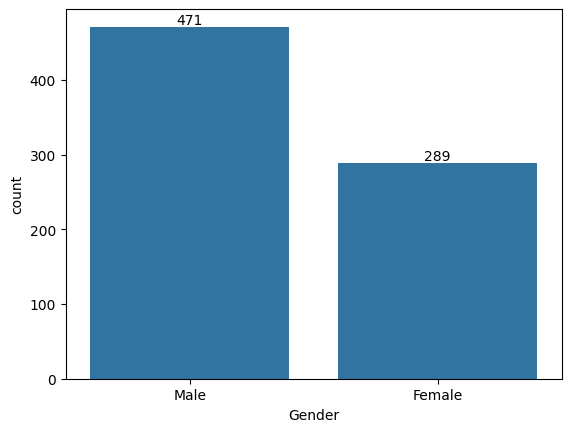

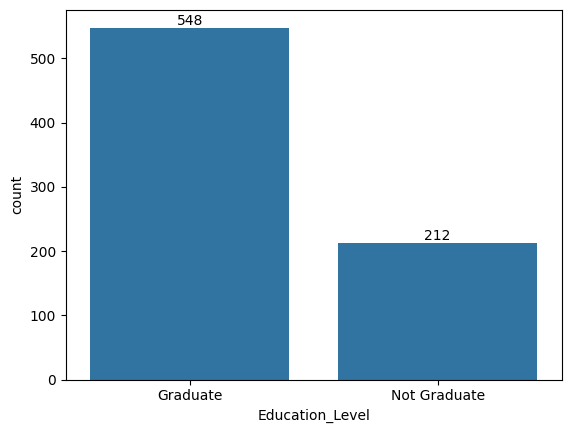

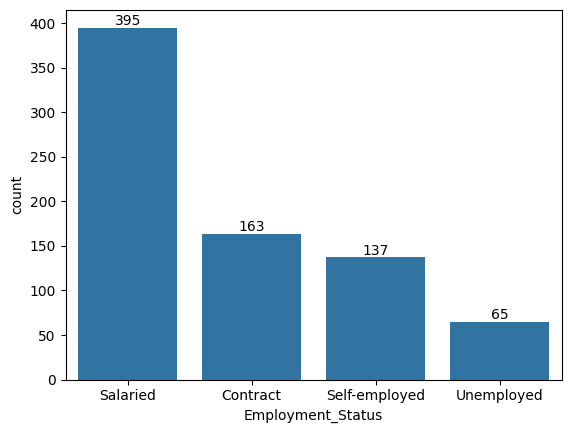

In [37]:
# Categorical distributions
gender_cnt = X_train["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])
plt.show()

edu_cnt = X_train["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])
plt.show()

emp_cnt = X_train["Employment_Status"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])
plt.show()

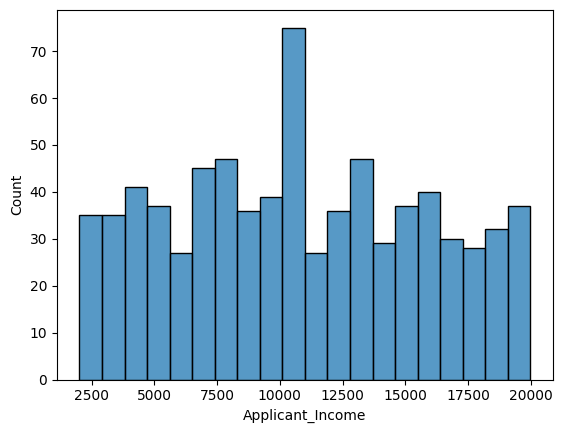

In [38]:
# Income Analysis
sns.histplot(data=X_train, x="Applicant_Income", bins=20)
plt.show()

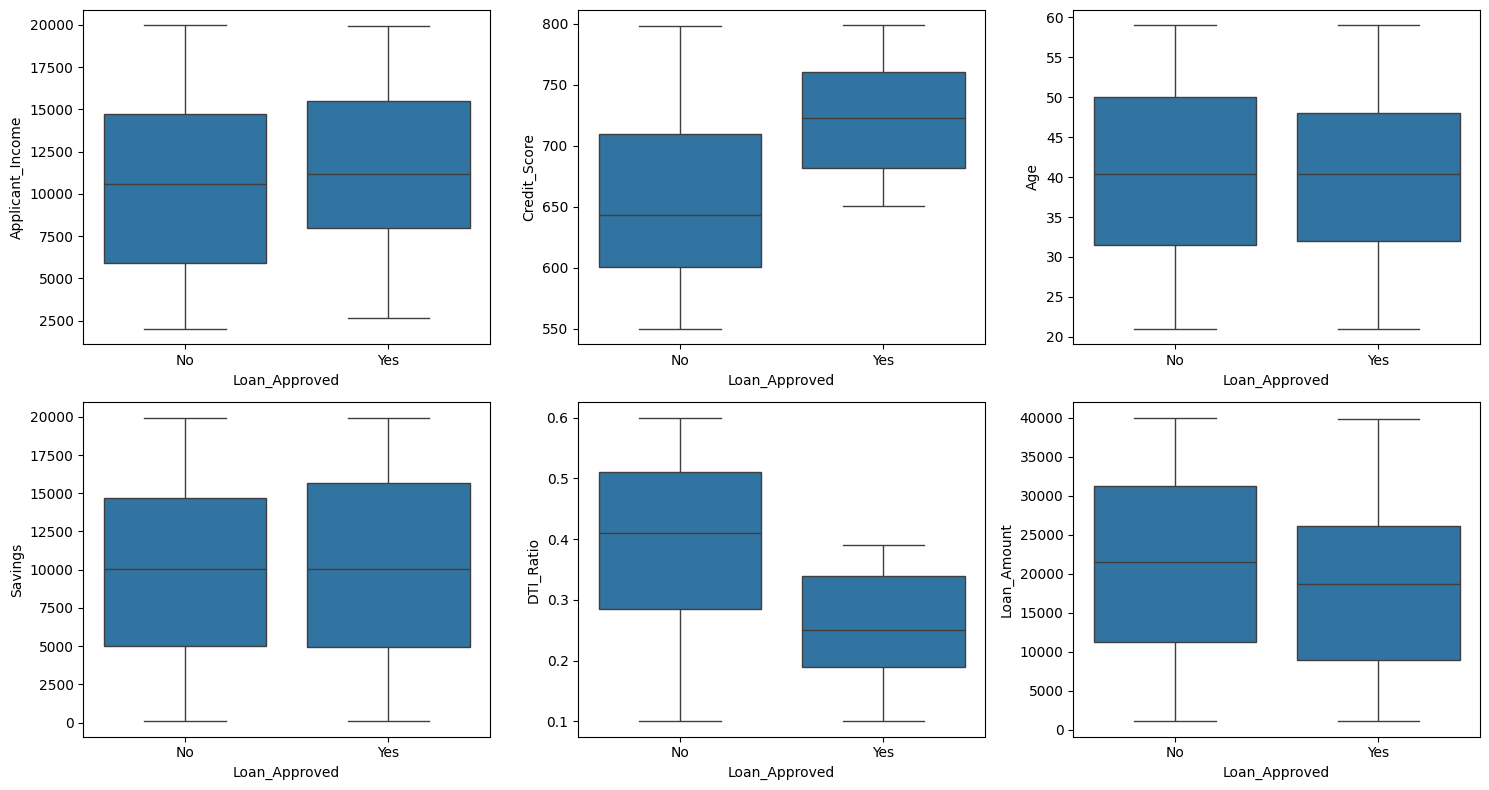

In [39]:
# Boxplots vs target
train_eda = X_train.copy()
train_eda["Loan_Approved"] = y_train.values

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
sns.boxplot(ax=axes[0,0], data=train_eda, x="Loan_Approved", y="Applicant_Income")
sns.boxplot(ax=axes[0,1], data=train_eda, x="Loan_Approved", y="Credit_Score")
sns.boxplot(ax=axes[0,2], data=train_eda, x="Loan_Approved", y="Age")
sns.boxplot(ax=axes[1,0], data=train_eda, x="Loan_Approved", y="Savings")
sns.boxplot(ax=axes[1,1], data=train_eda, x="Loan_Approved", y="DTI_Ratio")
sns.boxplot(ax=axes[1,2], data=train_eda, x="Loan_Approved", y="Loan_Amount")
plt.tight_layout()
plt.show()


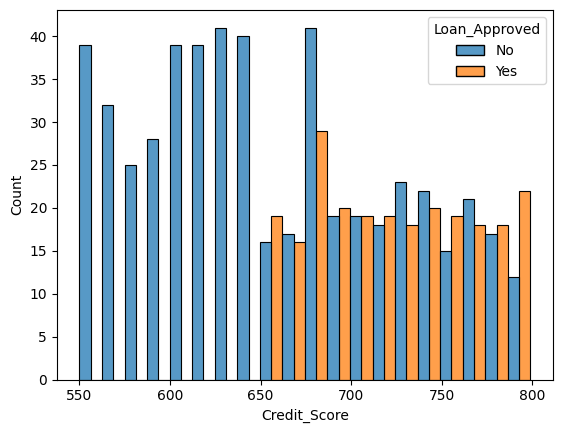

In [40]:
# Credit score vs approval
sns.histplot(data=train_eda, x="Credit_Score", hue="Loan_Approved", bins=20, multiple="dodge")
plt.show()

## Step 4: Encoding

In [41]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

# Target encoding
le_target = LabelEncoder()
y_train = le_target.fit_transform(y_train)
y_test = le_target.transform(y_test)

# Label encode Education_Level
le = LabelEncoder()
X_train["Education_Level"] = le.fit_transform(X_train["Education_Level"])
X_test["Education_Level"] = le.transform(X_test["Education_Level"])

# One-hot encode remaining categoricals
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded_train = ohe.fit_transform(X_train[cols])
encoded_train_df = pd.DataFrame(encoded_train, columns=ohe.get_feature_names_out(cols), index=X_train.index)

encoded_test = ohe.transform(X_test[cols])
encoded_test_df = pd.DataFrame(encoded_test, columns=ohe.get_feature_names_out(cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=cols), encoded_train_df], axis=1)
X_test = pd.concat([X_test.drop(columns=cols), encoded_test_df], axis=1)

In [42]:
train_with_target = X_train.copy()
train_with_target["Loan_Approved"] = y_train

corr_matrix = train_with_target.select_dtypes(include=["number"]).corr()

corr_mat = corr_matrix["Loan_Approved"].sort_values(ascending=False)
print(corr_mat)

Loan_Approved                      1.000000
Credit_Score                       0.457766
Applicant_Income                   0.131670
Employer_Category_MNC              0.048668
Collateral_Value                   0.047033
Coapplicant_Income                 0.034615
Marital_Status_Single              0.033846
Loan_Purpose_Personal              0.026599
Savings                            0.017290
Property_Area_Urban                0.015675
Loan_Purpose_Home                 -0.000628
Property_Area_Semiurban           -0.001095
Loan_Purpose_Education            -0.001223
Dependents                        -0.007247
Employer_Category_Private         -0.010680
Employment_Status_Self-employed   -0.012727
Employer_Category_Unemployed      -0.016095
Age                               -0.020847
Existing_Loans                    -0.040989
Employer_Category_Government      -0.043894
Employment_Status_Salaried        -0.046491
Education_Level                   -0.051366
Employment_Status_Unemployed    

## Step 5: Feature Scaling

In [43]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

## Model Training & Evaluation

In [44]:
# Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION")
print("Precision Score:",precision_score(y_test, y_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


LOGISTIC REGRESSION
Precision Score: 0.8937586390217969
Recall: 0.8947368421052632
Accuracy: 0.8947368421052632
F1: 0.8932106913050651
Confusion Matrix:
 [[122   7]
 [ 13  48]]


In [45]:
# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)
# print(pd.Series(y_train).value_counts())
print(le_target.classes_)

# print("KNN")
# print("Precision Score:",precision_score(y_test, y_pred, average="weighted", zero_division=0))
# print("Recall:", recall_score(y_test, y_pred, average="weighted"))
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("F1:", f1_score(y_test, y_pred, average="weighted"))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

['No' 'Yes']


In [46]:
# Naiye Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred = nb_model.predict(X_test_scaled)

print("NAIVE BAYES")
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall:", recall_score(y_test, y_pred, average="weighted"))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred, average="weighted"))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

NAIVE BAYES
Precision: 0.8853806248143155
Recall: 0.8842105263157894
Accuracy: 0.8842105263157894
F1: 0.88046783625731
Confusion Matrix:
 [[124   5]
 [ 17  44]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       129
           1       0.90      0.72      0.80        61

    accuracy                           0.88       190
   macro avg       0.89      0.84      0.86       190
weighted avg       0.89      0.88      0.88       190

